Vazifa

Quyidagi ma'lumotlar to'plami Hindistonning Qandli diabet va buyrak kasalliklari milliy institutidan olingan. Maqsad diagnostik o'lchovlar asosida bemorda diabet bor-yo'qligini taxmin qilishdir.


Tarkib

Dataset ichida barcha bemorlar kamida 21 yoshli ayollari.





Ustunlar





Pregnancies: homilador bo'lish soni



Glucose: glyukozaga test natijasi



BloodPressure: diastolik qon bosimi (mm Hg)



SkinThickness: Triceps teri burmasining qalinligi (mm)



Insulin: 2 soatlik sarum insulini (mu U/ml)



BMI: Tana massasi indeksi (vazn kg / (m bo'yi) ^ 2)



DiabetesPedigreeFunction: diabetning naslchilik funktsiyasi



Age: Yosh (yil)



Outcome: Class (0 - diabet yo'q, 1 - diabet)

In [50]:
import numpy as np
import pandas as pd

URL = 'https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/diabetes.csv'
df = pd.read_csv(URL)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [32]:
df.shape

(768, 9)

In [33]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [34]:
# Bazi ustunlarda 0 qiymatlar mavjud bu noto'g'ri qiymat ularni median bilan to'ldirib olamiz
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [35]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, jaccard_score

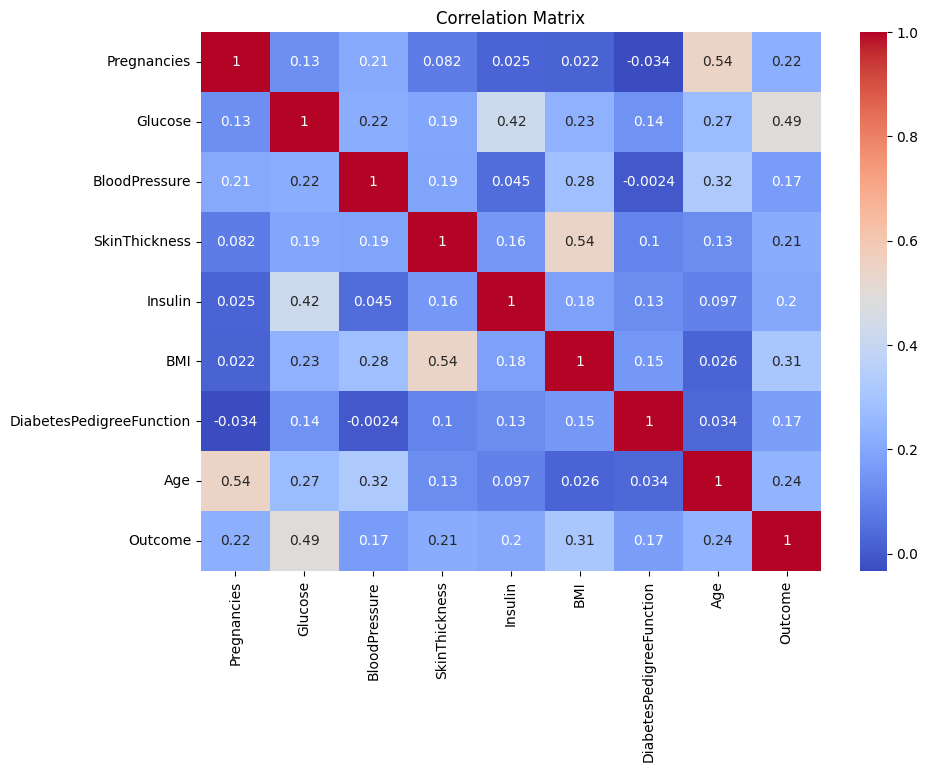

In [37]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [38]:
# Train va test uchun qismlarni ajratib olamiz. Malumotlar kam bo'lganligi bois test_size=0.1 qilib olamiz
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [39]:
# Malumotlarni 0 va 1 oraligiga tushurib olishimiz uchun standartscalerdan foydalandik
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
# Eng yaxshi K ni topaib olamiz
k_values = range(1, 31)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring='jaccard').mean()
    scores.append(cv_score)

best_k = k_values[scores.index(max(scores))]

print("Best K:", best_k)

Best K: 29


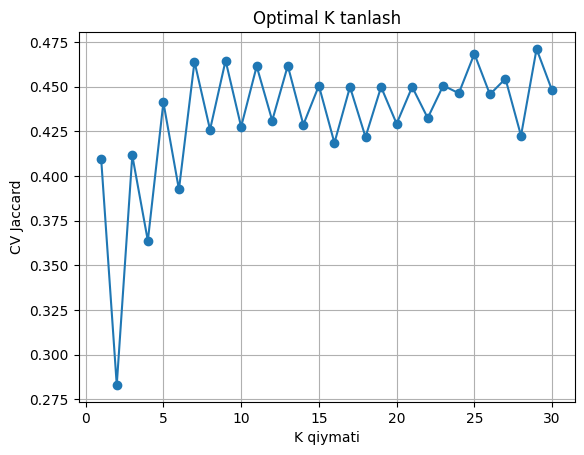

In [41]:
#K ni topganimizni grafik orqali ko'rib olamiz
plt.plot(k_values, scores, marker='o')
plt.xlabel("K qiymati")
plt.ylabel("CV Jaccard")
plt.title("Optimal K tanlash")
plt.grid()
plt.show()

In [42]:
# Modelni qurib olamiz k=23
knn = KNeighborsClassifier(n_neighbors=23)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [43]:
#Confusion matrix orqali TP, TN, FP, FN larni chiqarib olamiz
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[42  8]
 [12 15]]


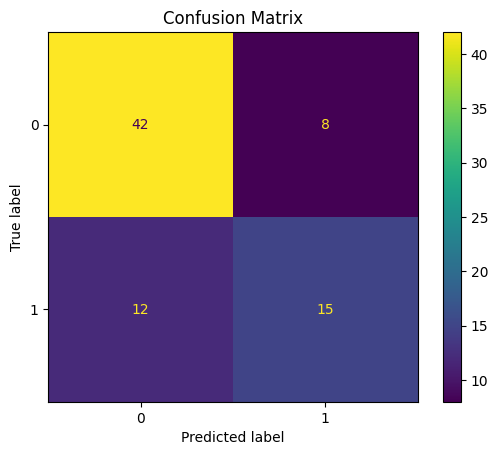

In [44]:
# Grafik orqali
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

In [45]:
#Jaccard
jaccard = jaccard_score(y_test, y_pred)
print("Jaccard:", jaccard)

Jaccard: 0.42857142857142855


In [51]:
#
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        50
           1       0.65      0.56      0.60        27

    accuracy                           0.74        77
   macro avg       0.71      0.70      0.70        77
weighted avg       0.73      0.74      0.73        77



In [47]:
#f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.6


In [48]:
#recall_score
recall = recall_score(y_test, y_pred)
print("Recall Score:", recall)

Recall Score: 0.5555555555555556


In [49]:
print("Optimal k =", best_k)
print("Jaccard Index =", round(jaccard, 3))
print("Accuracy =", round(accuracy_score(y_test, y_pred), 3))
print("Recall =", round(recall, 3))
print("F1 Score =", round(f1, 3))

Optimal k = 29
Jaccard Index = 0.429
Accuracy = 0.74
Recall = 0.556
F1 Score = 0.6


🧾 Qisqa xulosa

Accuracy = 0.74 → o‘rtacha

Recall = 0.556 → diabetni yaxshi topmayapti ❗

F1 = 0.6, Jaccard = 0.429 → o‘rtacha

👉 Muammo: FN ko‘p (kasalni sog‘lom deyapti)
👉 Sabab: k=23 katta → model o‘rtachalashtirib yuborgan

Xulosa: model bor, lekin diagnostika uchun yetarli emas — recallni oshirish kerak.